# Lecture 1 - Introduction to the Vacuum World

In this notebook we will introduce the concept of `environment`, `agent` and we will try to compare a `random_agent` against a simple `reflex agent`.

In [1]:
# this is something we will run each time at the beginning of our notebook
# in order to access the modules present in scripts
from pathlib import Path
import sys

ROOT = Path.cwd()
while not (ROOT / "scripts").exists():
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT))

# and then we import the module as scripts.module_name
from scripts.environment import *
from scripts.agent import RandomAgent
from scripts.runner import run_episode

import inspect

## Environment

An environment...

### The Vacuum World

Description of the vacuum world (at this stage of the implementation, difficulty = 0).

If someone want to add some sprites, well, it is **really, but really welcome**!

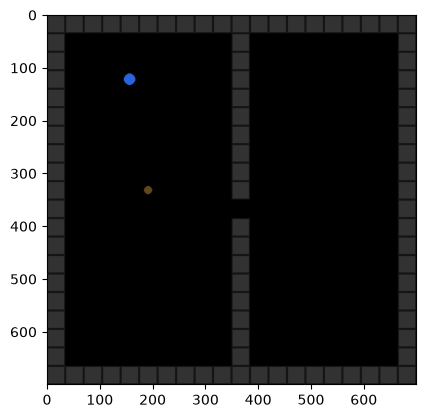

In [5]:
env = VacuumWorld(render_mode=RenderMode.RGB_ARRAY, observation_type=ObservationType.IMAGE)
frame = env._get_obs()

from matplotlib import pyplot as plt

plt.imshow(frame)
plt.show()

## Agent

An agent, as defined in chapter 2.1 of the *Artificial Intelligence: A Modern Approach* book, is anything that can perceive its environment through sensors, and act upon that environment through actuators based on its agent program. This can be a dog, a robot, or even you. As long as you can perceive the environment and act on it, you are an agent. This notebook will explain how to implement a simple agent, create an environment, and implement a program that helps the agent act on the environment based on its percepts.

We will use object of the class `Agent`. Let's import it.

### Random Agent

A random agent program, as the name suggests, chooses an action at random, without taking into account the percepts.\
Here, we will demonstrate a random vacuum agent for a trivial vacuum environment, that is, the two-state environment.

In [3]:
print(inspect.getsource(RandomAgent))

class RandomAgent(Agent):
    """Random agent."""

    def __init__(self, env : gym.Env):
        """Just take the actions from the enviornment as basic knowledge"""
        self.action_space = env.action_space

    def act(self, observation: Any):
        """Observation are not actually used"""
        return self.action_space.sample()



So, what does our `RandomAgent` do?\
Well pretty much it initializes itself by taking down the possible actions (all) and once it has to act it just acts randomly.

Don't be scared by the `gym.Env`: in this serie of notebooks we will use the **Gymnasium Protocol**, a well established protocol to deal with agents (especially in Reinforcement Learning Scenarios, but we will adapt it). You can find more about it in [this documentation here](https://gymnasium.farama.org/introduction/basic_usage/).

So don't bother it and let's see the agent in action!

We will render the scene with PyGame. Personally I find it really enjoyable, maybe look at its [documentation here](https://www.pygame.org/docs/).

In [4]:
# let's see a random agent in action

### Simple Reflex Agent

A simple reflex agent program selects actions on the basis of the current percept, ignoring the rest of the percept history.\
These agents work on a condition-action rule (also called situation-action rule, production or if-then rule), which tells the agent the action to trigger when a particular situation is encountered.